# Stage 0: Setup and Data Loading

In this stage, we download the Air Quality dataset from Kaggle and load it into a Pandas DataFrame.

In [1]:
import kagglehub
import os
import shutil
import pandas as pd

# Download latest version
try:
    path = kagglehub.dataset_download("rohanrao/air-quality-data-in-india")
    print("Source path from kagglehub:", path)
    
    # Define local dataset directory
    local_dir = "dataset"
    if not os.path.exists(local_dir):
        os.makedirs(local_dir)
        print(f"Created local directory: {local_dir}")
    
    # Copy files to local directory
    for filename in os.listdir(path):
        src_file = os.path.join(path, filename)
        dst_file = os.path.join(local_dir, filename)
        if os.path.isfile(src_file):
            shutil.copy2(src_file, dst_file)
            print(f"Copied {filename} to local {local_dir} folder.")

except Exception as e:
    print(f"Could not download dataset: {e}")
    print("Please ensure you have an internet connection or have downloaded the dataset manually.")

c:\College_Computer_Science\Semester 6\Soft Comp\soft-computing-mid-term\ai_train\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Source path from kagglehub: C:\Users\User\.cache\kagglehub\datasets\rohanrao\air-quality-data-in-india\versions\12
Copied city_day.csv to local dataset folder.
Copied city_hour.csv to local dataset folder.
Copied stations.csv to local dataset folder.
Copied station_day.csv to local dataset folder.
Copied station_hour.csv to local dataset folder.


In [ ]:
# Load the city_day.csv file from the local dataset folder
csv_path = os.path.join("dataset", "city_day.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    # Filter only necessary columns and remove missing values
    df = df[['PM2.5', 'NO2', 'AQI']].dropna()
    
    print(f"Dataset loaded and cleaned successfully. Remaining rows: {len(df)}")
    print("First 5 rows of cleaned data:")
    display(df.head())
else:
    print(f"File not found: {csv_path}. Did the download or file copying stage fail?")

Dataset loaded and cleaned successfully. Remaining rows: 23849
First 5 rows of cleaned data:


,PM2.5,NO2,AQI
28,83.13,28.71,209.0
29,79.84,28.68,328.0
30,94.52,32.66,514.0
31,135.99,42.08,782.0
32,178.33,35.31,914.0


# Stage 1: Manual Fuzzy Inference System (Sugeno) for Air Quality

Study Case: Predicting Air Quality Index (AQI) based on PM2.5 and NO2 levels.

We use fuzzy logic to map environmental sensor data into human-readable air quality categories.

In [3]:
from helper import fuzzify, evaluate_rule, sugeno_defuzzification
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Membership Function (MF) Definitions

We define two inputs based on Indian Air Quality standards:
- **PM2.5**: Particulate Matter 2.5 (Low, Medium, High).
- **NO2**: Nitrogen Dioxide (Low, Medium, High).

And one output:
- **AQI**: Air Quality Index (Zero-order Sugeno constants).

In [4]:
# PM2.5 (0-500 range)
pm25_mf = {
    'Low': ('left_shoulder', [30, 60]),
    'Medium': ('triangular', [45, 90, 135]),
    'High': ('right_shoulder', [110, 200])
}

# NO2 (0-400 range)
no2_mf = {
    'Low': ('left_shoulder', [40, 80]),
    'Medium': ('triangular', [60, 130, 200]),
    'High': ('right_shoulder', [160, 300])
}

## 2. Rule Base Definitions

Rules determine the resulting AQI constant based on input states:

In [5]:
rule_base = [
    {'if': [('pm2.5', 'High'), ('no2', 'High')], 'then': 500},   # Severe
    {'if': [('pm2.5', 'High'), ('no2', 'Medium')], 'then': 350}, # Very Poor
    {'if': [('pm2.5', 'High'), ('no2', 'Low')], 'then': 250},    # Poor
    {'if': [('pm2.5', 'Medium'), ('no2', 'High')], 'then': 350}, # Very Poor
    {'if': [('pm2.5', 'Medium'), ('no2', 'Medium')], 'then': 150}, # Moderate
    {'if': [('pm2.5', 'Medium'), ('no2', 'Low')], 'then': 100},    # Satisfactory
    {'if': [('pm2.5', 'Low'), ('no2', 'High')], 'then': 250},    # Poor
    {'if': [('pm2.5', 'Low'), ('no2', 'Medium')], 'then': 100},    # Satisfactory
    {'if': [('pm2.5', 'Low'), ('no2', 'Low')], 'then': 50}       # Good
]

## 3. Inference Function

In [6]:
def predict_aqi(pm25_val, no2_val):
    # Fuzzification
    p_fuzzy = fuzzify(pm25_val, pm25_mf)
    n_fuzzy = fuzzify(no2_val, no2_mf)
    
    memberships = {'pm2.5': p_fuzzy, 'no2': n_fuzzy}
    
    # Rule Evaluation
    firing_strengths = []
    rule_outputs = []
    
    for rule in rule_base:
        w, z = evaluate_rule(memberships, rule)
        firing_strengths.append(w)
        rule_outputs.append(z)
        
    # Defuzzification (Sugeno)
    return sugeno_defuzzification(firing_strengths, rule_outputs)

# Test Case 1: High Pollution (PM2.5: 220, NO2: 320)
print(f"Predicted AQI (High Pollution): {predict_aqi(220, 320):.2f}")

# Test Case 2: Clean Air (PM2.5: 15, NO2: 20)
print(f"Predicted AQI (Clean Air): {predict_aqi(15, 20):.2f}")

# Test Case 3: Moderate Conditions (PM2.5: 90, NO2: 130)
print(f"Predicted AQI (Moderate): {predict_aqi(90, 130):.2f}")

Predicted AQI (High Pollution): 500.00
Predicted AQI (Clean Air): 50.00
Predicted AQI (Moderate): 150.00


# Stage 2: Validation with Real-World Data (Delhi)

In this stage, we take real pollutant measurements from the city of **Delhi** and run them through our manual fuzzy logic system to see how well it approximates the official AQI.

In [7]:
# 1. Filter and Clean Data for Delhi
# Since the global 'df' is now filtered to 3 columns in Stage 0, we reload to filter by City
csv_path = os.path.join("dataset", "city_day.csv")

if os.path.exists(csv_path):
    # Load raw data to allow filtering by City
    raw_df = pd.read_csv(csv_path)
    delhi_df = raw_df[raw_df['City'] == 'Delhi'].copy()
    
    # Select columns and drop NaNs
    delhi_df = delhi_df[['Date', 'PM2.5', 'NO2', 'AQI']].dropna()
    delhi_df['Date'] = pd.to_datetime(delhi_df['Date'])
    
    print(f'Cleaned data points for Delhi: {len(delhi_df)}')
    display(delhi_df.head())
else:
    print(f'File not found: {csv_path}.')

Cleaned data points for Delhi: 1998


,Date,PM2.5,NO2,AQI
10229,2015-01-01,313.22,36.39,472.0
10230,2015-01-02,186.18,32.87,454.0
10231,2015-01-03,87.18,30.31,143.0
10232,2015-01-04,151.84,36.91,319.0
10233,2015-01-05,146.60,34.92,325.0


In [8]:
# 2. Apply Fuzzy Inference to the dataset
print('Calculating predicted AQI for all rows...')
delhi_df['Predicted_AQI'] = delhi_df.apply(
    lambda row: predict_aqi(row['PM2.5'], row['NO2']), axis=1
)

print('Inference complete.')
display(delhi_df[['Date', 'AQI', 'Predicted_AQI']].head())

Calculating predicted AQI for all rows...
Inference complete.


,Date,AQI,Predicted_AQI
10229,2015-01-01,472.0,250.0
10230,2015-01-02,454.0,250.0
10231,2015-01-03,143.0,100.0
10232,2015-01-04,319.0,250.0
10233,2015-01-05,325.0,250.0


## Visualization: Actual vs Predicted AQI

We plot the official AQI against our fuzzy logic predictions to visualize the accuracy of our manual rules.

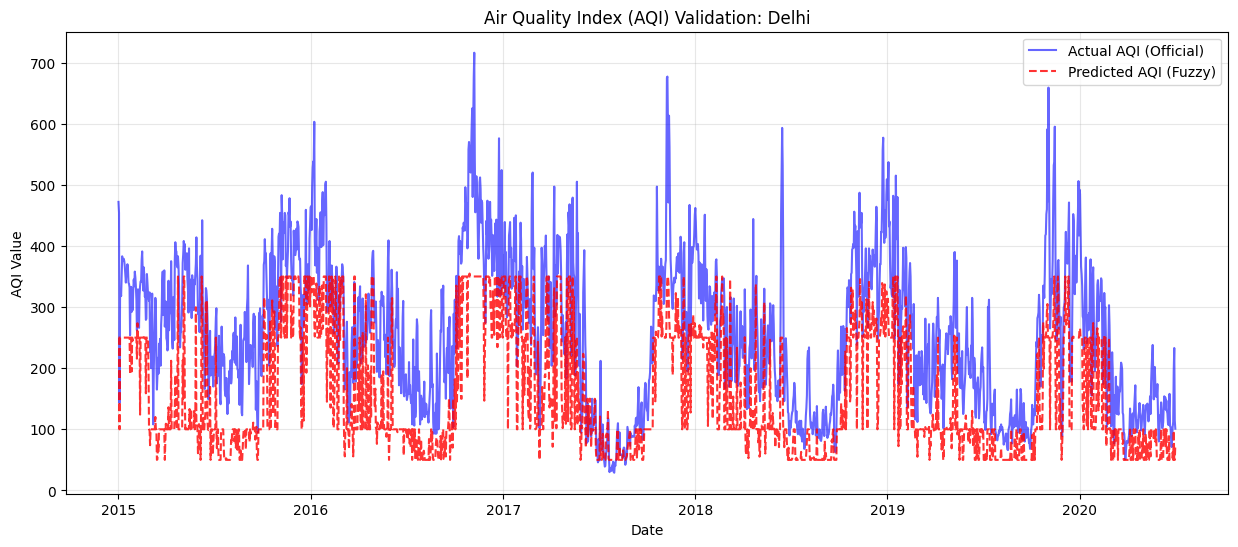

Mean Absolute Error of Manual Fuzzy System: 103.33


In [9]:
# 3. Visualization
plt.figure(figsize=(15, 6))
plt.plot(delhi_df['Date'], delhi_df['AQI'], label='Actual AQI (Official)', color='blue', alpha=0.6)
plt.plot(delhi_df['Date'], delhi_df['Predicted_AQI'], label='Predicted AQI (Fuzzy)', color='red', linestyle='--', alpha=0.8)

plt.title('Air Quality Index (AQI) Validation: Delhi')
plt.xlabel('Date')
plt.ylabel('AQI Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Simple Accuracy Metric: Mean Absolute Error
mae = (delhi_df['AQI'] - delhi_df['Predicted_AQI']).abs().mean()
print(f'Mean Absolute Error of Manual Fuzzy System: {mae:.2f}')

# Stage 3: Evolutionary Tuning dengan Genetic Algorithm (GA)

Pada tahap ini, kita menggunakan **Genetic Algorithm (GA)** untuk mengoptimasi dua hal secara bersamaan:

1. **Parameter Membership Function (MF)** — titik-titik batas (center & width) dari setiap MF triangular/shoulder pada PM2.5 dan NO2.
2. **Rule Weights** — bobot kontribusi setiap rule dalam defuzzifikasi Sugeno (nilai 0–1, efektif menonaktifkan rule yang tidak berguna).

**Representasi Kromosom:**
```
[ pm25_mf_params (6 nilai) | no2_mf_params (6 nilai) | rule_weights (9 nilai) ]
```
Total 21 gen per individu.

**Fungsi Fitness:** Meminimalkan MAE (Mean Absolute Error) pada data Delhi.


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from copy import deepcopy

# ── Reproduksi helper functions lokal (agar GA independen dari file helper.py) ──

def _left_shoulder(x, a, b):
    """Nilai MF untuk left shoulder: 1 jika x<=a, linear turun di [a,b], 0 jika x>=b."""
    if b <= a:
        return 1.0 if x <= a else 0.0
    if x <= a:
        return 1.0
    elif x >= b:
        return 0.0
    else:
        return (b - x) / (b - a)

def _right_shoulder(x, a, b):
    """Nilai MF untuk right shoulder: 0 jika x<=a, linear naik di [a,b], 1 jika x>=b."""
    if b <= a:
        return 1.0 if x >= b else 0.0
    if x <= a:
        return 0.0
    elif x >= b:
        return 1.0
    else:
        return (x - a) / (b - a)

def _triangular(x, a, b, c):
    """Nilai MF untuk triangular: naik dari a ke b, turun dari b ke c."""
    if x <= a or x >= c:
        return 0.0
    elif x <= b:
        return (x - a) / (b - a) if b != a else 1.0
    else:
        return (c - x) / (c - b) if c != b else 1.0

def fuzzify_local(value, mf_dict):
    """Hitung derajat keanggotaan untuk semua kategori."""
    result = {}
    for label, (mf_type, params) in mf_dict.items():
        if mf_type == 'left_shoulder':
            result[label] = _left_shoulder(value, *params)
        elif mf_type == 'right_shoulder':
            result[label] = _right_shoulder(value, *params)
        elif mf_type == 'triangular':
            result[label] = _triangular(value, *params)
        else:
            result[label] = 0.0
    return result

def predict_aqi_custom(pm25_val, no2_val, pm25_mf_c, no2_mf_c, rule_base_c, rule_weights_c):
    """Inferensi Sugeno dengan MF dan rule weights kustom."""
    p_fuzzy = fuzzify_local(pm25_val, pm25_mf_c)
    n_fuzzy = fuzzify_local(no2_val, no2_mf_c)
    memberships = {'pm2.5': p_fuzzy, 'no2': n_fuzzy}

    firing = []
    outputs = []
    for i, rule in enumerate(rule_base_c):
        w = 1.0
        for (var, label) in rule['if']:
            w = min(w, memberships[var].get(label, 0.0))
        w *= rule_weights_c[i]  # terapkan rule weight
        firing.append(w)
        outputs.append(rule['then'])

    total_w = sum(firing)
    if total_w == 0:
        return 0.0
    return sum(f * z for f, z in zip(firing, outputs)) / total_w

print("✅ Helper functions lokal siap digunakan.")


In [ ]:
# ── Batas pencarian (search bounds) untuk setiap parameter ──
# PM2.5 MF: Low=[a,b], Medium=[a,b,c], High=[a,b]  →  6 parameter
# NO2 MF:  Low=[a,b], Medium=[a,b,c], High=[a,b]   →  6 parameter
# Rule weights: 9 nilai antara [0, 1]

PM25_BOUNDS = [
    (0,   50),   # Low.a
    (20, 120),   # Low.b
    (20, 100),   # Med.a
    (60, 150),   # Med.b (peak)
    (80, 200),   # Med.c
    (80, 300),   # High.a
    (120, 400),  # High.b
]

NO2_BOUNDS = [
    (0,   80),   # Low.a
    (20, 150),   # Low.b
    (20, 120),   # Med.a
    (60, 200),   # Med.b (peak)
    (100, 300),  # Med.c
    (100, 350),  # High.a
    (150, 400),  # High.b
]

RULE_WEIGHT_BOUNDS = [(0.0, 1.0)] * 9  # 9 rules

ALL_BOUNDS = PM25_BOUNDS + NO2_BOUNDS + RULE_WEIGHT_BOUNDS
CHROM_LEN = len(ALL_BOUNDS)
print(f"Panjang kromosom: {CHROM_LEN} gen")
print(f"  • PM2.5 MF params : {len(PM25_BOUNDS)}")
print(f"  • NO2 MF params   : {len(NO2_BOUNDS)}")
print(f"  • Rule weights    : {len(RULE_WEIGHT_BOUNDS)}")

# Template rule base (bagian 'then' tetap dari Stage 1)
RULE_TEMPLATE = [
    {'if': [('pm2.5', 'High'),   ('no2', 'High')],   'then': 500},
    {'if': [('pm2.5', 'High'),   ('no2', 'Medium')], 'then': 350},
    {'if': [('pm2.5', 'High'),   ('no2', 'Low')],    'then': 250},
    {'if': [('pm2.5', 'Medium'), ('no2', 'High')],   'then': 350},
    {'if': [('pm2.5', 'Medium'), ('no2', 'Medium')], 'then': 150},
    {'if': [('pm2.5', 'Medium'), ('no2', 'Low')],    'then': 100},
    {'if': [('pm2.5', 'Low'),    ('no2', 'High')],   'then': 250},
    {'if': [('pm2.5', 'Low'),    ('no2', 'Medium')], 'then': 100},
    {'if': [('pm2.5', 'Low'),    ('no2', 'Low')],    'then': 50},
]

def decode_chromosome(chrom):
    """Ubah kromosom (list float) menjadi MF dict + rule_weights."""
    p = chrom  # alias

    # -- PM2.5 MF --
    pm25_mf_c = {
        'Low':    ('left_shoulder',  [p[0], p[1]]),
        'Medium': ('triangular',     [p[2], p[3], p[4]]),
        'High':   ('right_shoulder', [p[5], p[6]]),
    }

    # -- NO2 MF --
    no2_mf_c = {
        'Low':    ('left_shoulder',  [p[7],  p[8]]),
        'Medium': ('triangular',     [p[9],  p[10], p[11]]),
        'High':   ('right_shoulder', [p[12], p[13]]),
    }

    # -- Rule weights --
    rule_weights = list(p[14:23])

    return pm25_mf_c, no2_mf_c, rule_weights

def random_chromosome():
    """Buat kromosom acak dalam batas yang valid."""
    chrom = [random.uniform(lo, hi) for lo, hi in ALL_BOUNDS]
    return enforce_order(chrom)

def enforce_order(chrom):
    """Pastikan urutan parameter MF monoton (a<=b<=c) agar shape MF valid."""
    c = list(chrom)
    # PM2.5: Low.a <= Low.b
    c[0], c[1] = sorted([c[0], c[1]])
    # PM2.5 Medium: a <= peak <= c
    c[2], c[3], c[4] = sorted([c[2], c[3], c[4]])
    # PM2.5 High: a <= b
    c[5], c[6] = sorted([c[5], c[6]])
    # NO2: sama
    c[7],  c[8]  = sorted([c[7],  c[8]])
    c[9],  c[10], c[11] = sorted([c[9], c[10], c[11]])
    c[12], c[13] = sorted([c[12], c[13]])
    return c

print("✅ Encoding/decoding kromosom siap.")


In [ ]:
def compute_mae(chrom, data_pm25, data_no2, data_aqi):
    """Hitung MAE untuk satu kromosom pada dataset."""
    pm25_mf_c, no2_mf_c, rule_weights = decode_chromosome(chrom)
    preds = np.array([
        predict_aqi_custom(p, n, pm25_mf_c, no2_mf_c, RULE_TEMPLATE, rule_weights)
        for p, n in zip(data_pm25, data_no2)
    ])
    return np.mean(np.abs(preds - data_aqi))

def fitness(chrom, data_pm25, data_no2, data_aqi):
    """Fitness = 1/(1+MAE) agar lebih besar = lebih baik."""
    return 1.0 / (1.0 + compute_mae(chrom, data_pm25, data_no2, data_aqi))

# ── Operator Genetik ──

def tournament_selection(population, fitnesses, k=3):
    """Pilih 1 individu terbaik dari k kandidat acak."""
    candidates = random.sample(range(len(population)), k)
    best = max(candidates, key=lambda i: fitnesses[i])
    return population[best][:]

def blend_crossover(parent1, parent2, alpha=0.5):
    """BLX-α crossover: anak berada dalam rentang [min-α*range, max+α*range]."""
    child = []
    for g1, g2, (lo, hi) in zip(parent1, parent2, ALL_BOUNDS):
        lo_g, hi_g = min(g1, g2), max(g1, g2)
        r = hi_g - lo_g
        new_lo = max(lo, lo_g - alpha * r)
        new_hi = min(hi, hi_g + alpha * r)
        child.append(random.uniform(new_lo, new_hi) if new_lo < new_hi else lo_g)
    return enforce_order(child)

def gaussian_mutation(chrom, mutation_rate=0.15, sigma_frac=0.1):
    """Mutasi Gaussian: tambah noise proporsional terhadap range batas."""
    mutated = list(chrom)
    for i, (lo, hi) in enumerate(ALL_BOUNDS):
        if random.random() < mutation_rate:
            sigma = sigma_frac * (hi - lo)
            mutated[i] = np.clip(mutated[i] + random.gauss(0, sigma), lo, hi)
    return enforce_order(mutated)

# ── Main GA Loop ──

def run_ga(data_pm25, data_no2, data_aqi,
           pop_size=60, n_generations=80,
           crossover_rate=0.8, mutation_rate=0.15,
           elitism=3, seed=42):
    """
    Jalankan Genetic Algorithm.
    
    Returns
    -------
    best_chrom      : kromosom terbaik
    best_mae_hist   : list MAE terbaik per generasi
    avg_mae_hist    : list MAE rata-rata per generasi
    """
    random.seed(seed)
    np.random.seed(seed)

    # Inisialisasi populasi
    population = [random_chromosome() for _ in range(pop_size)]
    
    best_mae_hist = []
    avg_mae_hist  = []
    best_chrom    = None
    best_mae      = float('inf')

    print(f"{'Gen':>5} | {'Best MAE':>10} | {'Avg MAE':>10} | {'Improvement':>12}")
    print("-" * 46)

    for gen in range(n_generations):
        # Evaluasi fitness
        fitnesses = [fitness(c, data_pm25, data_no2, data_aqi) for c in population]
        maes      = [compute_mae(c, data_pm25, data_no2, data_aqi) for c in population]

        gen_best_mae = min(maes)
        gen_avg_mae  = np.mean(maes)
        best_mae_hist.append(gen_best_mae)
        avg_mae_hist.append(gen_avg_mae)

        # Update global best
        if gen_best_mae < best_mae:
            best_mae   = gen_best_mae
            best_chrom = population[np.argmin(maes)][:]
            improved   = "⬆ improved"
        else:
            improved = ""

        if gen % 10 == 0 or improved:
            print(f"{gen+1:>5} | {gen_best_mae:>10.2f} | {gen_avg_mae:>10.2f} | {improved}")

        # Elitism: pertahankan individu terbaik
        sorted_idx  = sorted(range(pop_size), key=lambda i: maes[i])
        new_pop     = [population[i][:] for i in sorted_idx[:elitism]]

        # Buat generasi baru
        while len(new_pop) < pop_size:
            p1 = tournament_selection(population, fitnesses)
            if random.random() < crossover_rate:
                p2    = tournament_selection(population, fitnesses)
                child = blend_crossover(p1, p2)
            else:
                child = p1[:]
            child = gaussian_mutation(child, mutation_rate)
            new_pop.append(child)

        population = new_pop

    print(f"\n✅ GA selesai. Best MAE = {best_mae:.4f}")
    return best_chrom, best_mae_hist, avg_mae_hist

print("✅ GA engine siap.")


In [ ]:
# ── Load & prep data (sama seperti Stage 2) ──
import os, pandas as pd

csv_path = os.path.join("dataset", "city_day.csv")
raw_df   = pd.read_csv(csv_path)
delhi_df = raw_df[raw_df['City'] == 'Delhi'][['Date','PM2.5','NO2','AQI']].dropna()
delhi_df['Date'] = pd.to_datetime(delhi_df['Date'])

data_pm25 = delhi_df['PM2.5'].values
data_no2  = delhi_df['NO2'].values
data_aqi  = delhi_df['AQI'].values

print(f"Data Delhi siap: {len(delhi_df)} baris")

# ── Hitung MAE baseline (Stage 1 manual) ──
pm25_mf_manual = {
    'Low':    ('left_shoulder',  [30, 60]),
    'Medium': ('triangular',     [45, 90, 135]),
    'High':   ('right_shoulder', [110, 200]),
}
no2_mf_manual = {
    'Low':    ('left_shoulder',  [40, 80]),
    'Medium': ('triangular',     [60, 130, 200]),
    'High':   ('right_shoulder', [160, 300]),
}
rule_weights_manual = [1.0] * 9

mae_baseline = np.mean(np.abs(
    np.array([predict_aqi_custom(p, n, pm25_mf_manual, no2_mf_manual, RULE_TEMPLATE, rule_weights_manual)
              for p, n in zip(data_pm25, data_no2)]) - data_aqi
))
print(f"\n📌 MAE Baseline (Tahap 1 Manual FIS): {mae_baseline:.2f}")

# ── Jalankan GA ──
print("\n🔄 Menjalankan Genetic Algorithm...")
best_chrom, best_mae_hist, avg_mae_hist = run_ga(
    data_pm25, data_no2, data_aqi,
    pop_size     = 60,
    n_generations= 80,
    mutation_rate= 0.15,
    seed         = 42
)

mae_ga = best_mae_hist[-1]
print(f"\n📌 MAE Setelah GA Tuning (Tahap 3):  {mae_ga:.2f}")
print(f"📉 Penurunan MAE: {mae_baseline - mae_ga:.2f} ({(mae_baseline - mae_ga)/mae_baseline*100:.1f}% improvement)")


In [ ]:
# ── Tampilkan parameter optimal hasil GA ──
pm25_mf_ga, no2_mf_ga, rw_ga = decode_chromosome(best_chrom)

print("=" * 55)
print("  PARAMETER OPTIMAL HASIL GENETIC ALGORITHM")
print("=" * 55)

print("\n📐 PM2.5 Membership Functions:")
for label, (mf_type, params) in pm25_mf_ga.items():
    formatted = [f"{v:.1f}" for v in params]
    print(f"   {label:8s} ({mf_type:>14s}): {formatted}")

print("\n📐 NO2 Membership Functions:")
for label, (mf_type, params) in no2_mf_ga.items():
    formatted = [f"{v:.1f}" for v in params]
    print(f"   {label:8s} ({mf_type:>14s}): {formatted}")

print("\n⚖️  Rule Weights (9 rules):")
for i, (rule, w) in enumerate(zip(RULE_TEMPLATE, rw_ga)):
    conds = " AND ".join([f"{var.upper()}={lbl}" for var, lbl in rule['if']])
    status = "✅" if w >= 0.3 else "❌ (lemah)"
    print(f"   Rule {i+1}: {conds:40s} → w={w:.3f} {status}")

print("\n📊 Perbandingan Manual vs GA:")
print(f"   MAE Manual FIS : {mae_baseline:.2f}")
print(f"   MAE GA Tuned   : {mae_ga:.2f}")
print(f"   Selisih        : {mae_baseline - mae_ga:.2f} ({(mae_baseline-mae_ga)/mae_baseline*100:.1f}%)")


In [ ]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ────────────────────────────────────────────────
# 1. Konvergensi GA
# ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(best_mae_hist, color='royalblue', linewidth=2, label='Best MAE per Generasi')
ax1.plot(avg_mae_hist,  color='orange',    linewidth=1.5, linestyle='--', alpha=0.8, label='Avg MAE per Generasi')
ax1.axhline(mae_baseline, color='red', linestyle=':', linewidth=1.5, label=f'Baseline Manual FIS ({mae_baseline:.1f})')
ax1.set_title('Kurva Konvergensi Genetic Algorithm', fontsize=13, fontweight='bold')
ax1.set_xlabel('Generasi'); ax1.set_ylabel('MAE')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.annotate(f'Final MAE: {mae_ga:.2f}',
             xy=(len(best_mae_hist)-1, mae_ga),
             xytext=(-60, 20), textcoords='offset points',
             arrowprops=dict(arrowstyle='->', color='royalblue'),
             color='royalblue', fontsize=10)

# ────────────────────────────────────────────────
# 2. MF PM2.5: Manual vs GA
# ────────────────────────────────────────────────
x_pm = np.linspace(0, 400, 500)
colors_mf = {'Low': 'green', 'Medium': 'orange', 'High': 'red'}

ax2 = fig.add_subplot(gs[1, 0])
for label, (mf_type, params) in pm25_mf_manual.items():
    y = [fuzzify_local(v, {'x': (mf_type, params)})['x'] for v in x_pm]
    ax2.plot(x_pm, y, color=colors_mf[label], linewidth=2, label=label)
ax2.set_title('PM2.5 MF — Manual (Tahap 1)', fontsize=11); ax2.set_xlabel('PM2.5'); ax2.set_ylabel('μ')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_ylim(-0.05, 1.1)

ax3 = fig.add_subplot(gs[1, 1])
for label, (mf_type, params) in pm25_mf_ga.items():
    y = [fuzzify_local(v, {'x': (mf_type, params)})['x'] for v in x_pm]
    ax3.plot(x_pm, y, color=colors_mf[label], linewidth=2, label=label)
ax3.set_title('PM2.5 MF — GA Tuned (Tahap 3)', fontsize=11); ax3.set_xlabel('PM2.5'); ax3.set_ylabel('μ')
ax3.legend(); ax3.grid(True, alpha=0.3); ax3.set_ylim(-0.05, 1.1)

# ────────────────────────────────────────────────
# 3. Rule Weights Bar Chart
# ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
rule_labels = [f"R{i+1}" for i in range(9)]
bar_colors  = ['steelblue' if w >= 0.3 else 'salmon' for w in rw_ga]
bars = ax4.bar(rule_labels, rw_ga, color=bar_colors, edgecolor='white', linewidth=0.5)
ax4.axhline(0.3, color='gray', linestyle='--', linewidth=1, label='Threshold 0.3')
ax4.set_title('Rule Weights Hasil GA', fontsize=11); ax4.set_xlabel('Rule'); ax4.set_ylabel('Weight')
ax4.set_ylim(0, 1.05); ax4.legend(); ax4.grid(True, alpha=0.3, axis='y')
for bar, w in zip(bars, rw_ga):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{w:.2f}', ha='center', va='bottom', fontsize=8)

# ────────────────────────────────────────────────
# 4. Predicted vs Actual (Manual vs GA, scatter)
# ────────────────────────────────────────────────
preds_manual = np.array([
    predict_aqi_custom(p, n, pm25_mf_manual, no2_mf_manual, RULE_TEMPLATE, rule_weights_manual)
    for p, n in zip(data_pm25, data_no2)
])
preds_ga = np.array([
    predict_aqi_custom(p, n, pm25_mf_ga, no2_mf_ga, RULE_TEMPLATE, rw_ga)
    for p, n in zip(data_pm25, data_no2)
])

ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(data_aqi, preds_manual, alpha=0.3, s=8, color='red',      label=f'Manual (MAE={mae_baseline:.1f})')
ax5.scatter(data_aqi, preds_ga,     alpha=0.3, s=8, color='royalblue', label=f'GA Tuned (MAE={mae_ga:.1f})')
lim = max(data_aqi.max(), preds_ga.max()) * 1.05
ax5.plot([0, lim], [0, lim], 'k--', linewidth=1, label='Ideal (y=x)')
ax5.set_title('Actual vs Predicted AQI (Scatter)', fontsize=11)
ax5.set_xlabel('Actual AQI'); ax5.set_ylabel('Predicted AQI')
ax5.legend(fontsize=8); ax5.grid(True, alpha=0.3)

plt.suptitle('Tahap 3: Genetic Algorithm Tuning — Hasil Optimasi FIS', 
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('ga_tuning_results.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Visualisasi tersimpan sebagai ga_tuning_results.png")


In [ ]:
# ── Visualisasi Time-Series: Actual vs Manual vs GA ──
plt.figure(figsize=(16, 5))
plt.plot(delhi_df['Date'], data_aqi,      label='Actual AQI',        color='black',      linewidth=1.2, alpha=0.8)
plt.plot(delhi_df['Date'], preds_manual,  label=f'Manual FIS  (MAE={mae_baseline:.1f})', color='red',   linewidth=1,   linestyle='--', alpha=0.7)
plt.plot(delhi_df['Date'], preds_ga,      label=f'GA Tuned    (MAE={mae_ga:.1f})', color='royalblue', linewidth=1, linestyle='-.', alpha=0.85)

plt.title('Perbandingan AQI: Actual vs Manual FIS vs GA Tuned (Delhi)', fontsize=13, fontweight='bold')
plt.xlabel('Tanggal'); plt.ylabel('AQI')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('aqi_comparison_timeseries.png', dpi=130, bbox_inches='tight')
plt.show()
print("✅ Time-series comparison tersimpan.")


In [ ]:
print("=" * 60)
print("  RINGKASAN HASIL — PERBANDINGAN TAHAP 1 vs TAHAP 3")
print("=" * 60)

r2_manual = 1 - np.sum((data_aqi - preds_manual)**2) / np.sum((data_aqi - data_aqi.mean())**2)
r2_ga     = 1 - np.sum((data_aqi - preds_ga)**2)     / np.sum((data_aqi - data_aqi.mean())**2)
rmse_m    = np.sqrt(np.mean((data_aqi - preds_manual)**2))
rmse_ga   = np.sqrt(np.mean((data_aqi - preds_ga)**2))

print(f"{'Metrik':<25} {'Manual FIS':>12} {'GA Tuned':>12} {'Δ':>10}")
print("-" * 62)
print(f"{'MAE':<25} {mae_baseline:>12.2f} {mae_ga:>12.2f} {mae_baseline-mae_ga:>+10.2f}")
print(f"{'RMSE':<25} {rmse_m:>12.2f} {rmse_ga:>12.2f} {rmse_m-rmse_ga:>+10.2f}")
print(f"{'R² Score':<25} {r2_manual:>12.4f} {r2_ga:>12.4f} {r2_ga-r2_manual:>+10.4f}")
print("=" * 62)
print(f"\n🏆 Peningkatan MAE  : {(mae_baseline - mae_ga)/mae_baseline*100:.1f}%")
print(f"🏆 Peningkatan RMSE : {(rmse_m - rmse_ga)/rmse_m*100:.1f}%")
print(f"🏆 Peningkatan R²   : {(r2_ga - r2_manual)/abs(r2_manual)*100:.1f}%")
print("\n📝 Catatan:")
print("   • GA mengoptimasi 7+7=14 parameter MF dan 9 rule weights")
print("   • Populasi: 60 individu | Generasi: 80 | Elitism: 3")
print("   • Operator: BLX-α crossover + Gaussian mutation")
